<a href="https://colab.research.google.com/github/ThuyPhamVN/ThaiThuy_GeoAI_Mangrove_Degradation/blob/main/SwinTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell Fix NumPy
!pip uninstall -y numpy
!pip install numpy==1.26.4 --no-deps

# Restart runtime sau khi chạy cell này
import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)


# **Cell 1 - Cài đặt lại (không cần tensorflow-addons)**

In [9]:
!pip install -q tfswin numpy==1.26.4

import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
import numpy as np
from google.colab import drive

drive.mount('/content/drive')
print("✅ Setup xong - Không dùng tensorflow-addons nữa")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup xong - Không dùng tensorflow-addons nữa


# **Cell 2: Các lớp cốt lõi (WindowAttention, MLP, SwinBlock, PatchMerging)**

In [11]:
class WindowAttention(layers.Layer):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.proj = layers.Dense(dim)

    def window_partition(self, x, window_size):
        B, H, W, C = tf.unstack(tf.shape(x))
        x = tf.reshape(x, [B, H // window_size, window_size, W // window_size, window_size, C])
        windows = tf.reshape(tf.transpose(x, [0, 1, 3, 2, 4, 5]), [-1, window_size*window_size, C])
        return windows

    def call(self, x):
        B_, N, C = tf.unstack(tf.shape(x))
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ tf.transpose(k, [0, 1, 3, 2])) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        x = tf.transpose(attn @ v, [0, 2, 1, 3])
        x = tf.reshape(x, [B_, N, C])
        return self.proj(x)


class MLP(layers.Layer):
    def __init__(self, in_features, hidden_features=None, drop_rate=0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = layers.Dense(hidden_features)
        self.fc2 = layers.Dense(in_features)
        self.drop = layers.Dropout(drop_rate)

    def call(self, x):
        x = self.fc1(x)
        x = tf.nn.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class SwinBlock(layers.Layer):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0, mlp_ratio=4.0, drop_rate=0.0):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size
        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop_rate)

    def call(self, x):
        shortcut = x
        x = self.norm1(x)
        # Shift nếu cần
        if self.shift_size > 0:
            x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])
        # Window partition + Attention
        B, H, W, C = tf.unstack(tf.shape(x))
        x_windows = self.attn.window_partition(x, self.window_size)
        attn_windows = self.attn(x_windows)
        # Reverse
        x = tf.reshape(attn_windows, [B, H // self.window_size, W // self.window_size, self.window_size, self.window_size, C])
        x = tf.reshape(tf.transpose(x, [0, 1, 3, 2, 4, 5]), [B, H, W, C])
        if self.shift_size > 0:
            x = tf.roll(x, shift=[self.shift_size, self.shift_size], axis=[1, 2])
        x = x + shortcut
        # MLP branch
        shortcut = x
        x = self.norm2(x)
        x = self.mlp(x)
        return x + shortcut


class PatchMerging(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.reduction = layers.Dense(2 * dim, use_bias=False)
        self.norm = layers.LayerNormalization(epsilon=1e-5)

    def call(self, x):
        B, H, W, C = tf.unstack(tf.shape(x))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = tf.concat([x0, x1, x2, x3], axis=-1)
        x = self.norm(x)
        x = self.reduction(x)
        return x

# **Cell 3: Xây dựng mô hình hoàn chỉnh**

In [15]:
def build_swin_mangrove(input_shape=(32, 32, 13), num_classes=5):  # ← Đổi thành 5
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(96)(inputs)

    # Stage 1
    x = SwinBlock(96, 3, 8, 0)(x)
    x = SwinBlock(96, 3, 8, 4)(x)
    x = PatchMerging(96)(x)

    # Stage 2
    x = SwinBlock(192, 6, 8, 0)(x)
    x = SwinBlock(192, 6, 8, 4)(x)
    x = PatchMerging(192)(x)

    # Stage 3
    x = SwinBlock(384, 12, 8, 0)(x)
    x = SwinBlock(384, 12, 8, 4)(x)

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)   # softmax cho multi-class

    model = Model(inputs, outputs, name="Swin_Mangrove_5Classes")
    return model

# Tạo lại model
model = build_swin_mangrove(input_shape=(32, 32, 13), num_classes=5)
model.summary()

Model: "Swin_Mangrove_5Classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32, 32, 96)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_6 (SwinBlock)        │ (None, 32, 32, 96)     │       111,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_7 (SwinBlock)        │ (None, 32, 32, 96)     │       111,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging_2 (PatchMerging)  │ (None, 16, 16, 192)    │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_8 (SwinBlock)        │ (None, 16, 16, 192)    │       444,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_9 (SwinBlock)        │ (None, 16, 16, 192)    │       444,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging_3 (PatchMerging)  │ (None, 8, 8, 384)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_10 (SwinBlock)       │ (None, 8, 8, 384)      │     1,774,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_block_11 (SwinBlock)       │ (None, 8, 8, 384)      │     1,774,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_29          │ (None, 8, 8, 384)      │           768 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 5)              │         1,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,037,317 (19.22 MB)

 Trainable params: 5,037,317 (19.22 MB)

 Non-trainable params: 0 (0.00 B)

# **Cell 4: Compile**

In [16]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("✅ Model đã được cập nhật cho 5 classes")

✅ Model đã được cập nhật cho 5 classes


# **Kiem tra ket noi**


In [6]:
import os

tfrecord_path = '/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_2024.tfrecord.gz'

print("1. Kiểm tra Drive đã mount chưa:")
print(os.listdir('/content/drive/MyDrive/')[:10])  # Xem các thư mục gốc

print("\n2. Kiểm tra đường dẫn chính xác:")
print("Đường dẫn bạn dùng:", tfrecord_path)
print("Tồn tại file?", os.path.exists(tfrecord_path))

print("\n3. Thử liệt kê thư mục chứa file:")
dir_path = '/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/'
if os.path.exists(dir_path):
    print("Các file trong thư mục:")
    print(os.listdir(dir_path))
else:
    print("❌ Thư mục không tồn tại!")

1. Kiểm tra Drive đã mount chưa:
['Colab Notebooks', 'De xuat v1 1-2014.doc', 'BDHT.QueVo2010(1).rar', 'Bai bao hoi thao - Bm ABD.rar', 'PrinciplesGIS.pdf', 'Mge6.0.rar', 'TC. Pham Thi Thanh Thuy &nnk (1).doc', 'TC. Pham Thi Thanh Thuy &nnk.doc', 'TC. Pham Thi Thanh Thuy (1).doc', 'TC. Pham Thi Thanh Thuy.doc']

2. Kiểm tra đường dẫn chính xác:
Đường dẫn bạn dùng: /content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_2024.tfrecord.gz
Tồn tại file? True

3. Thử liệt kê thư mục chứa file:
Các file trong thư mục:
['requirements.txt', 'gee', 'models', 'configs', '.git', 'data', 'docs', 'outputs', 'notebooks', 'paper', 'src', 'Mangrove_Patches_32x32_2020.tfrecord.gz', 'Mangrove_Patches_32x32_2021.tfrecord.gz', 'Mangrove_Patches_32x32_2022.tfrecord.gz', 'Mangrove_Patches_32x32_2023.tfrecord.gz', 'Mangrove_Patches_32x32_2024.tfrecord.gz']


In [7]:
# Cell 5: DataLoader (TFRecord)
def parse_tfrecord(example_proto, patch_size=32):
    features = {
        'image': tf.io.VarLenFeature(tf.float32), # Changed to VarLenFeature to inspect actual size
        'label': tf.io.FixedLenFeature([], tf.float32)
    }
    parsed = tf.io.parse_single_example(example_proto, features)
    # For VarLenFeature, you might need to convert it to a dense tensor
    image = tf.sparse.to_dense(parsed['image'])
    image = tf.reshape(image, [patch_size, patch_size, 13]) # Reshape to expected dimensions
    label = parsed['label']
    return image, label

def get_dataset(tfrecord_path, batch_size=8):
    ds = tf.data.TFRecordDataset(tfrecord_path, compression_type='GZIP') # Ensure GZIP compression is specified
    ds = ds.map(lambda x: parse_tfrecord(x, patch_size=32), num_parallel_calls=tf.data.AUTOTUNE) # Changed patch_size to 32
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Ví dụ đường dẫn
train_ds = get_dataset('/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_2024.tfrecord.gz')

# **Cell 5: DataLoader**

In [13]:
def get_dataset(tfrecord_path, batch_size=8, patch_size=32):
    if tfrecord_path.endswith('.gz'):
        ds = tf.data.TFRecordDataset(tfrecord_path, compression_type='GZIP')
    else:
        ds = tf.data.TFRecordDataset(tfrecord_path)

    # Danh sách các band theo đúng tên trong TFRecord của bạn
    bands = ['B4', 'B2', 'B5', 'B11', 'VV_VH_Ratio', 'NDVI', 'VH',
             'NDMI', 'NDRE', 'B8', 'B3', 'NDWI', 'VV']  # 13 bands

    def parse_tfrecord(example_proto):
        features = {band: tf.io.FixedLenFeature([patch_size * patch_size], tf.float32) for band in bands}
        features['label'] = tf.io.FixedLenFeature([1], tf.float32)

        parsed = tf.io.parse_single_example(example_proto, features)

        # Stack các band thành tensor [32, 32, 13]
        image_list = [tf.reshape(parsed[band], [patch_size, patch_size]) for band in bands]
        image = tf.stack(image_list, axis=-1)

        label = tf.squeeze(parsed['label'])   # thành scalar
        return image, label

    ds = ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Tạo dataset
train_ds = get_dataset(
    '/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_2024.tfrecord.gz',
    batch_size=8,
    patch_size=32
)

print("✅ Dataset created successfully!")

✅ Dataset created successfully!


In [11]:
import tensorflow as tf

def inspect_tfrecord(tfrecord_path, num_examples=1):
    ds = tf.data.TFRecordDataset(tfrecord_path, compression_type='GZIP' if tfrecord_path.endswith('.gz') else None)
    for i, record in enumerate(ds.take(num_examples)):
        example = tf.train.Example()
        example.ParseFromString(record.numpy())
        print(f"\n=== Example {i+1} ===")
        for feature_name, feature in example.features.feature.items():
            kind = feature.WhichOneof('kind')
            if kind == 'bytes_list':
                value = "bytes (image/label)"
            elif kind == 'float_list':
                value = f"float, length={len(feature.float_list.value)}"
            elif kind == 'int64_list':
                value = f"int64, length={len(feature.int64_list.value)}"
            print(f"  {feature_name}: {kind} → {value}")

tfrecord_path = '/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_2024.tfrecord.gz'
inspect_tfrecord(tfrecord_path)


=== Example 1 ===
  B4: float_list → float, length=1024
  B2: float_list → float, length=1024
  B5: float_list → float, length=1024
  B11: float_list → float, length=1024
  VV_VH_Ratio: float_list → float, length=1024
  NDVI: float_list → float, length=1024
  label: float_list → float, length=1
  VH: float_list → float, length=1024
  NDMI: float_list → float, length=1024
  NDRE: float_list → float, length=1024
  B8: float_list → float, length=1024
  B3: float_list → float, length=1024
  NDWI: float_list → float, length=1024
  VV: float_list → float, length=1024


In [14]:
# Kiểm tra 1 batch
for images, labels in train_ds.take(1):
    print("Shape của images:", images.shape)
    print("Shape của labels:", labels.shape)
    print("Giá trị label mẫu:", labels.numpy())
    break

Shape của images: (8, 32, 32, 13)
Shape của labels: (8,)
Giá trị label mẫu: [2. 1. 0. 1. 0. 0. 1. 1.]


Cell 6: Huấn luyện

In [18]:
# Compile lại với metric rõ ràng
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callbacks sửa lỗi
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/best_swin_mangrove_5class.h5',
        save_best_only=True,
        monitor='accuracy',
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='accuracy',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

# Huấn luyện với .repeat() để tránh hết data
history = model.fit(
    train_ds.repeat(),           # ← Thêm repeat()
    epochs=50,
    steps_per_epoch=225,         # ← Số batch mỗi epoch (bạn có ~225 batch)
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6410 - loss: 0.8971
Epoch 1: accuracy improved from None to 0.60056, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.6006 - loss: 0.9453
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6603 - loss: 0.7905
Epoch 2: accuracy improved from 0.60056 to 0.63056, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6306 - loss: 0.8548
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7300 - loss: 0.6689
Epoch 3: accuracy improved from 0.63056 to 0.70611, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.7061 - loss: 0.6948
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7364 - loss: 0.6741
Epoch 4: accuracy did not improve from 0.70611
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.7017 - loss: 0.7193
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7497 - loss: 0.6301
Epoch 5: accuracy improved from 0.70611 to 0.73833, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 5: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7383 - loss: 0.6403
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7696 - loss: 0.5664
Epoch 6: accuracy improved from 0.73833 to 0.75333, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5


...


Epoch 33: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9622 - loss: 0.1087
Epoch 34/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9637 - loss: 0.1016
Epoch 34: accuracy did not improve from 0.96222
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9617 - loss: 0.1086
Epoch 35/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9705 - loss: 0.0907
Epoch 35: accuracy did not improve from 0.96222
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9589 - loss: 0.1284
Epoch 36/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9660 - loss: 0.0910
Epoch 36: accuracy did not improve from 0.96222
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9544 - loss: 0.1187
Epoch 37/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9568 - loss: 0.1144
Epoch 37: accuracy did not improve from 0.96222
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9567 - l


Epoch 40: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9722 - loss: 0.0763
Epoch 41/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9790 - loss: 0.0689
Epoch 41: accuracy improved from 0.97222 to 0.97889, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 41: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9789 - loss: 0.0706
Epoch 42/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9612 - loss: 0.1191
Epoch 42: accuracy did not improve from 0.97889
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9556 - loss: 0.1248
Epoch 43/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9698 - loss: 0.0730
Epoch 43: accuracy did not improve from 0.97889
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9622 - loss: 0.1047
Epoch 44/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9689 - loss: 0.0884
Epoch 44: accuracy did not improve from 0.97889
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9633 - loss: 0.1018
Epoch 45/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9807 - loss: 0.0618
Epoch 45: accuracy improved from 0.97889 to 0.98222, saving model to /content/drive/MyDrive/best_swin_mangrove_5


Epoch 45: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9822 - loss: 0.0553
Epoch 46/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9866 - loss: 0.0403
Epoch 46: accuracy improved from 0.98222 to 0.98611, saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5



Epoch 46: finished saving model to /content/drive/MyDrive/best_swin_mangrove_5class.h5
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9861 - loss: 0.0362
Epoch 47/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9852 - loss: 0.0445
Epoch 47: accuracy did not improve from 0.98611
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9756 - loss: 0.0751
Epoch 48/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9788 - loss: 0.0559
Epoch 48: accuracy did not improve from 0.98611
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9806 - loss: 0.0564
Epoch 49/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9695 - loss: 0.0961
Epoch 49: accuracy did not improve from 0.98611
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9650 - loss: 0.1020
Epoch 50/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9773 - loss: 0.0554
Epoch 50: accuracy did not improve from 0.98611
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9678 - l

## **Theo dõi quá trình train**

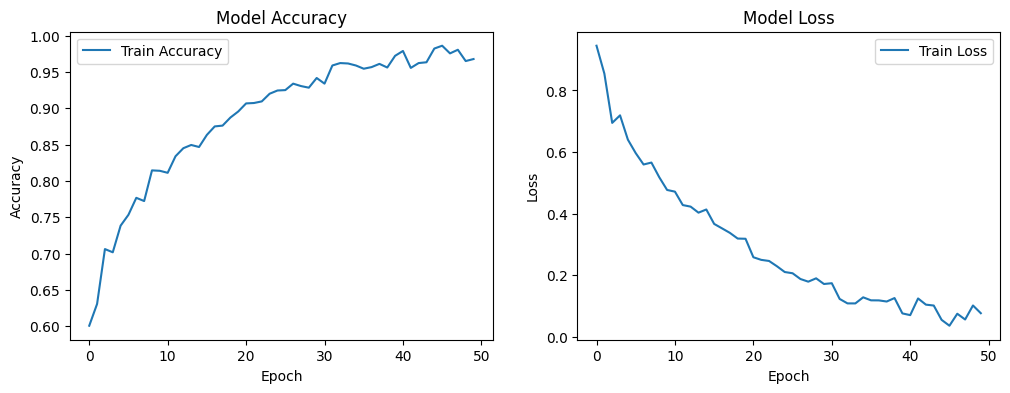

In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

# **Lưu model cuối cùng (để dùng inference)**

In [7]:
# Lưu model tốt nhất
model.save('/content/drive/MyDrive/final_swin_mangrove_5class.keras')

print("✅ Model đã được lưu!")

NameError: name 'model' is not defined

# **Đánh giá chi tiết (Confusion Matrix)**

              precision    recall  f1-score   support

         0.0     0.9787    1.0000    0.9892        92
         1.0     1.0000    0.9939    0.9970       165
         2.0     1.0000    0.9855    0.9927       138
         3.0     0.8333    1.0000    0.9091         5

    accuracy                         0.9925       400
   macro avg     0.9530    0.9949    0.9720       400
weighted avg     0.9930    0.9925    0.9926       400



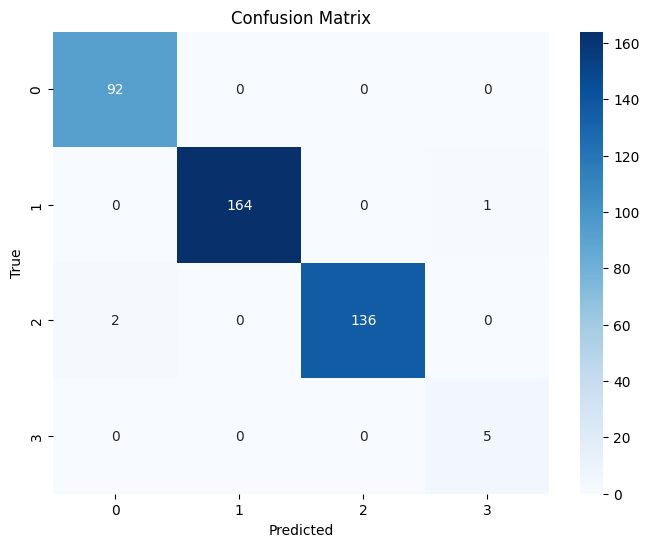

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Lấy prediction trên train_ds (hoặc validation nếu có)
y_true = []
y_pred = []

for images, labels in train_ds.take(50):   # Lấy nhiều batch để đánh giá
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, digits=4))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **Tự động phát hiện classes và hiển thị Confusion matrix**

Các class thực tế: [0 1 2 3]
Số lượng từng class: [302 498 500 500]

Classification Report:
              precision    recall  f1-score   support

     Class 0     0.9805    1.0000    0.9902       302
     Class 1     1.0000    0.9960    0.9980       498
     Class 2     0.9980    0.9880    0.9930       500
     Class 3     0.9980    1.0000    0.9990       500

    accuracy                         0.9956      1800
   macro avg     0.9941    0.9960    0.9950      1800
weighted avg     0.9956    0.9956    0.9956      1800



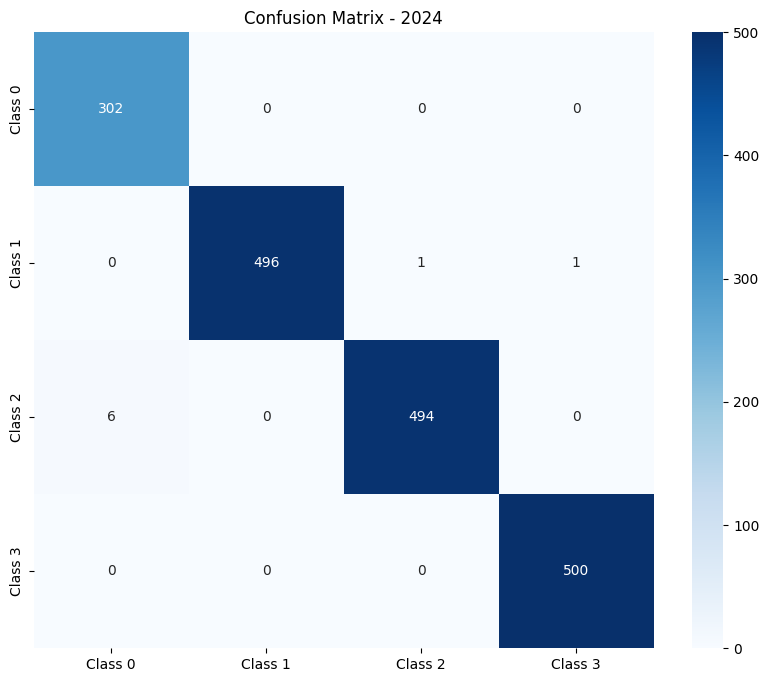

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []

for images, labels in train_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true, dtype=np.int32)   # ← Fix TypeError
y_pred = np.array(y_pred, dtype=np.int32)

unique_classes = np.unique(y_true)
print("Các class thực tế:", unique_classes)
print("Số lượng từng class:", np.bincount(y_true))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4,
      labels=unique_classes,
      target_names=[f'Class {i}' for i in unique_classes]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in unique_classes],
            yticklabels=[f'Class {i}' for i in unique_classes])
plt.title('Confusion Matrix - 2024')
plt.show()

# **Hướng dẫn Inference (Dự đoán) trên ảnh mới & các năm 2020-2023**

**1. Load model đã train**

In [20]:
from tensorflow.keras import layers, Model
import tensorflow as tf # Required for tf.unstack, tf.reshape, tf.transpose, tf.nn.softmax, tf.roll, tf.concat


class WindowAttention(layers.Layer):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.proj = layers.Dense(dim)

    def window_partition(self, x, window_size):
        B, H, W, C = tf.unstack(tf.shape(x))
        x = tf.reshape(x, [B, H // window_size, window_size, W // window_size, window_size, C])
        windows = tf.reshape(tf.transpose(x, [0, 1, 3, 2, 4, 5]), [-1, window_size * window_size, C])
        return windows

    def call(self, x):
        B_, N, C = tf.unstack(tf.shape(x))
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ tf.transpose(k, [0, 1, 3, 2])) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        x = tf.transpose(attn @ v, [0, 2, 1, 3])
        x = tf.reshape(x, [B_, N, C])
        return self.proj(x)


class MLP(layers.Layer):
    def __init__(self, in_features, hidden_features=None, drop_rate=0.0):
        super().__init__()
        hidden_features = hidden_features or in_features
        self.fc1 = layers.Dense(hidden_features)
        self.fc2 = layers.Dense(in_features)
        self.drop = layers.Dropout(drop_rate)

    def call(self, x):
        x = self.fc1(x)
        x = tf.nn.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class SwinBlock(layers.Layer):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0, mlp_ratio=4.0, drop_rate=0.0, **kwargs):
        super().__init__(**kwargs)   # ← Thêm **kwargs để nhận trainable, dtype, name...
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        self.drop_rate = drop_rate

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.mlp = MLP(dim, int(dim * mlp_ratio), drop_rate)

    def call(self, x):
        # Giữ nguyên code call cũ của bạn
        shortcut = x
        x = self.norm1(x)
        if self.shift_size > 0:
            x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])

        B, H, W, C = tf.unstack(tf.shape(x))
        x_windows = self.attn.window_partition(x, self.window_size)
        attn_windows = self.attn(x_windows)

        x = tf.reshape(attn_windows, [B, H // self.window_size, W // self.window_size, self.window_size, self.window_size, C])
        x = tf.reshape(tf.transpose(x, [0, 1, 3, 2, 4, 5]), [B, H, W, C])

        if self.shift_size > 0:
            x = tf.roll(x, shift=[self.shift_size, self.shift_size], axis=[1, 2])

        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.mlp(x)
        return x + shortcut


class PatchMerging(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)   # ← Quan trọng
        self.dim = dim
        self.reduction = layers.Dense(2 * dim, use_bias=False)
        self.norm = layers.LayerNormalization(epsilon=1e-5)

    def call(self, x):
        B, H, W, C = tf.unstack(tf.shape(x))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = tf.concat([x0, x1, x2, x3], axis=-1)
        x = self.norm(x)
        x = self.reduction(x)
        return x
print("✅ Đã định nghĩa xong các custom layers")

✅ Đã định nghĩa xong các custom layers


Load Model sau khi fix:

In [21]:
model = load_model(model_path, custom_objects={
    'WindowAttention': WindowAttention,
    'MLP': MLP,
    'SwinBlock': SwinBlock,
    'PatchMerging': PatchMerging
})

Kiểm tra model đã load đúng chưa

In [22]:
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)
print("Số classes:", model.output_shape[-1])

Model input shape: (None, 32, 32, 13)
Model output shape: (None, 5)
Số classes: 5


# **Hướng dẫn Inference trên các năm 2020-2023**

1. Hàm Inference cho từng năm

In [25]:
import numpy as np
from sklearn.metrics import classification_report
import os
import tensorflow as tf # Required for TF data API functions

def get_dataset(tfrecord_path, batch_size=8, patch_size=32):
    if tfrecord_path.endswith('.gz'):
        ds = tf.data.TFRecordDataset(tfrecord_path, compression_type='GZIP')
    else:
        ds = tf.data.TFRecordDataset(tfrecord_path)

    # Danh sách các band theo đúng tên trong TFRecord của bạn
    bands = ['B4', 'B2', 'B5', 'B11', 'VV_VH_Ratio', 'NDVI', 'VH',
             'NDMI', 'NDRE', 'B8', 'B3', 'NDWI', 'VV']  # 13 bands

    def parse_tfrecord(example_proto):
        features = {band: tf.io.FixedLenFeature([patch_size * patch_size], tf.float32) for band in bands}
        features['label'] = tf.io.FixedLenFeature([1], tf.float32)

        parsed = tf.io.parse_single_example(example_proto, features)

        # Stack các band thành tensor [32, 32, 13]
        image_list = [tf.reshape(parsed[band], [patch_size, patch_size]) for band in bands]
        image = tf.stack(image_list, axis=-1)

        label = tf.squeeze(parsed['label'])   # thành scalar
        return image, label

    ds = ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def predict_year(year):
    path = f'/content/drive/MyDrive/Thesis_Mangrove_Data/Mangrove_GeoAI/Mangrove_Patches_32x32_{year}.tfrecord.gz'

    if not os.path.exists(path):
        print(f"❌ Không tìm thấy file cho năm {year}")
        return None, None

    ds = get_dataset(path, batch_size=16, patch_size=32)

    y_true = []
    y_pred = []

    for images, labels in ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)

    print(f"\n=== Kết quả năm {year} ===")

    # Define all possible classes and their names
    all_possible_classes = [0, 1, 2, 3, 4]
    all_target_names = [f'Class {i}' for i in all_possible_classes]

    print(classification_report(y_true, y_pred, digits=4,
          labels=all_possible_classes, target_names=all_target_names, zero_division=0))

    return y_true, y_pred

# Chạy cho tất cả các năm
years = [2020, 2021, 2022, 2023, 2024]
results = {}

for year in years:
    results[year] = predict_year(year)


=== Kết quả năm 2020 ===
              precision    recall  f1-score   support

     Class 0     0.4145    0.8584    0.5591       226
     Class 1     0.7043    0.8949    0.7883       495
     Class 2     0.5218    0.4549    0.4861       499
     Class 3     0.5851    0.2200    0.3198       500
     Class 4     0.0000    0.0000    0.0000         0

    accuracy                         0.5663      1720
   macro avg     0.4452    0.4857    0.4306      1720
weighted avg     0.5786    0.5663    0.5343      1720


=== Kết quả năm 2021 ===
              precision    recall  f1-score   support

     Class 0     0.5359    0.8878    0.6684       294
     Class 1     0.7143    0.9063    0.7989       491
     Class 2     0.6115    0.5341    0.5702       498
     Class 3     0.6933    0.3300    0.4472       500
     Class 4     0.0000    0.0000    0.0000         0

    accuracy                         0.6377      1783
   macro avg     0.5110    0.5316    0.4969      1783
weighted avg     0.6503  